 ## Step 1.1: Import Required Libraries

We'll start by importing the necessary Python libraries for data analysis and visualization.

In [16]:
# 📦 Import Required Libraries

# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles for better visualization
sns.set(style="whitegrid")
plt.style.use("ggplot")


# Step 1.2: Load the Dataset

In [17]:
# 📁 Load the GHG Emission Dataset

# Replace the path below with the actual path if you're using a different environment
df = pd.read_csv(r"C:\Users\Priyanshu\Desktop\ghg ml model\Dataset\GHG_emission_dataset.csv")

# Show the shape and the column names
print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:\n", df.columns.tolist())


Dataset Shape: (10000, 19)

Column Names:
 ['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage', 'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions', 'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure', 'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions', 'SO2 Emissions', 'Emission Level']


# Step 1.3: Preview the Dataset and Check Data Types

This step helps you quickly get a feel for:

-What the first few records look like

-What types of data you're dealing with (numerical, categorical)

In [18]:
# 🔍 Preview the First 5 Rows of the Dataset
df.head()


,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
0,Motorcycle,Electric,2.747609,22,291288,49.083255,1.887738,Highway,Moderate,13.880458,52.883905,18.938861,955.411642,179.930088,1.085520,0.011548,0.096207,0.022936,Medium
1,Bus,Electric,5.743714,3,188398,23.460311,3.544147,City,Heavy,19.136947,5.697343,14.716526,1035.763062,250.505219,1.285628,0.187112,0.073321,0.028021,Medium
2,Bus,Hybrid,4.606368,17,281451,115.508350,4.646886,Highway,Free flow,8.123428,3.953116,18.644522,976.207064,404.979103,0.258189,0.132398,0.014744,0.075334,High
3,Truck,Electric,3.913024,4,151321,18.540217,3.581004,Rural,Heavy,35.994893,0.509678,11.951859,966.919462,463.568608,1.040956,0.166325,0.093490,0.025324,High
4,Truck,Hybrid,1.611297,15,91810,109.596566,3.879303,Highway,Moderate,14.793481,52.450884,2.761138,953.229351,79.514604,1.583390,0.078043,0.020396,0.024986,Low


In [19]:
# ℹ️ Check Dataset Info and Data Types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle Type        10000 non-null  object 
 1   Fuel Type           10000 non-null  object 
 2   Engine Size         10000 non-null  float64
 3   Age of Vehicle      10000 non-null  int64  
 4   Mileage             10000 non-null  int64  
 5   Speed               10000 non-null  float64
 6   Acceleration        10000 non-null  float64
 7   Road Type           10000 non-null  object 
 8   Traffic Conditions  10000 non-null  object 
 9   Temperature         10000 non-null  float64
 10  Humidity            10000 non-null  float64
 11  Wind Speed          10000 non-null  float64
 12  Air Pressure        10000 non-null  float64
 13  CO2 Emissions       10000 non-null  float64
 14  NOx Emissions       10000 non-null  float64
 15  PM2.5 Emissions     10000 non-null  float64
 16  VOC E

# Step 1.4: Check for Missing Values

In [20]:
# ❓ Check for Missing Values in Each Column
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])  # Show only columns with missing values

# ✅ If there are no missing values
if missing_values.sum() == 0:
    print("\nNo missing values detected in the dataset. We're good to go!")


Series([], dtype: int64)

No missing values detected in the dataset. We're good to go!


# Step 1.5: Visualize Emission Feature Distributions

We’ll look at how emissions like CO₂, NOₓ, PM2.5, VOC, and SO₂ are distributed across the dataset. This helps you understand the spread, skewness, and presence of outliers.



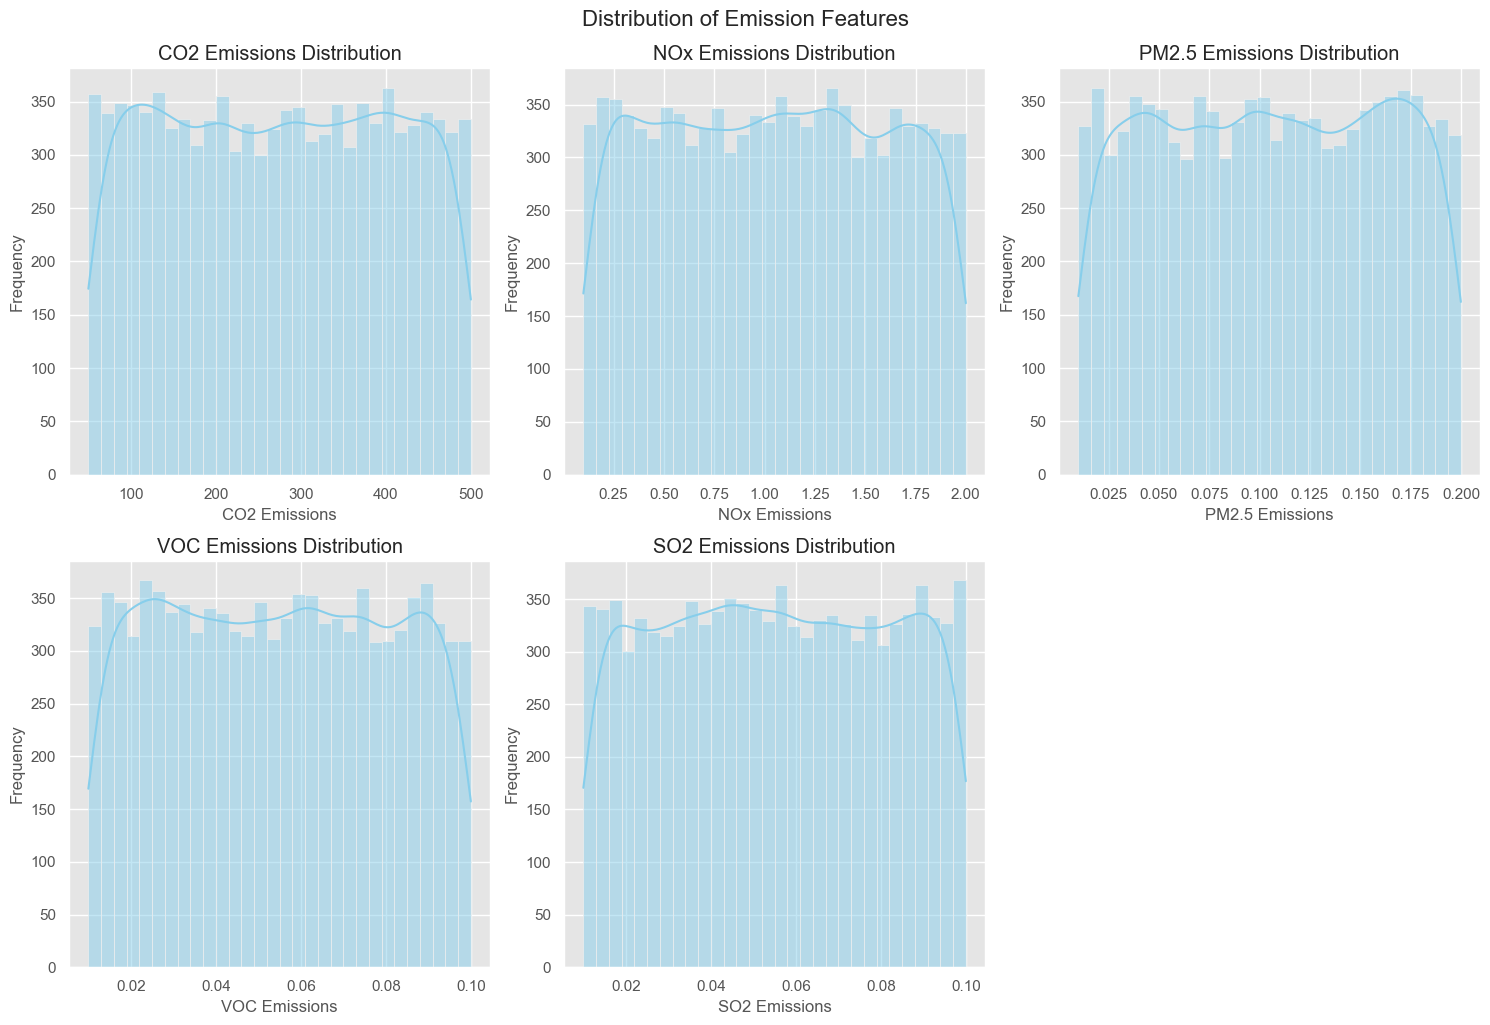

In [21]:
# 📊 Plot Histograms for Emission-Related Features

emission_cols = ['CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions', 'SO2 Emissions']

plt.figure(figsize=(15, 10))
for i, col in enumerate(emission_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()

plt.suptitle("Distribution of Emission Features", fontsize=16, y=1.02)
plt.show()


# Step 1.6: Correlation Heatmap

This step will help us:

-Identify highly correlated features

-Understand which inputs influence GHG emissions the most

-Avoid multicollinearity in ML modeling

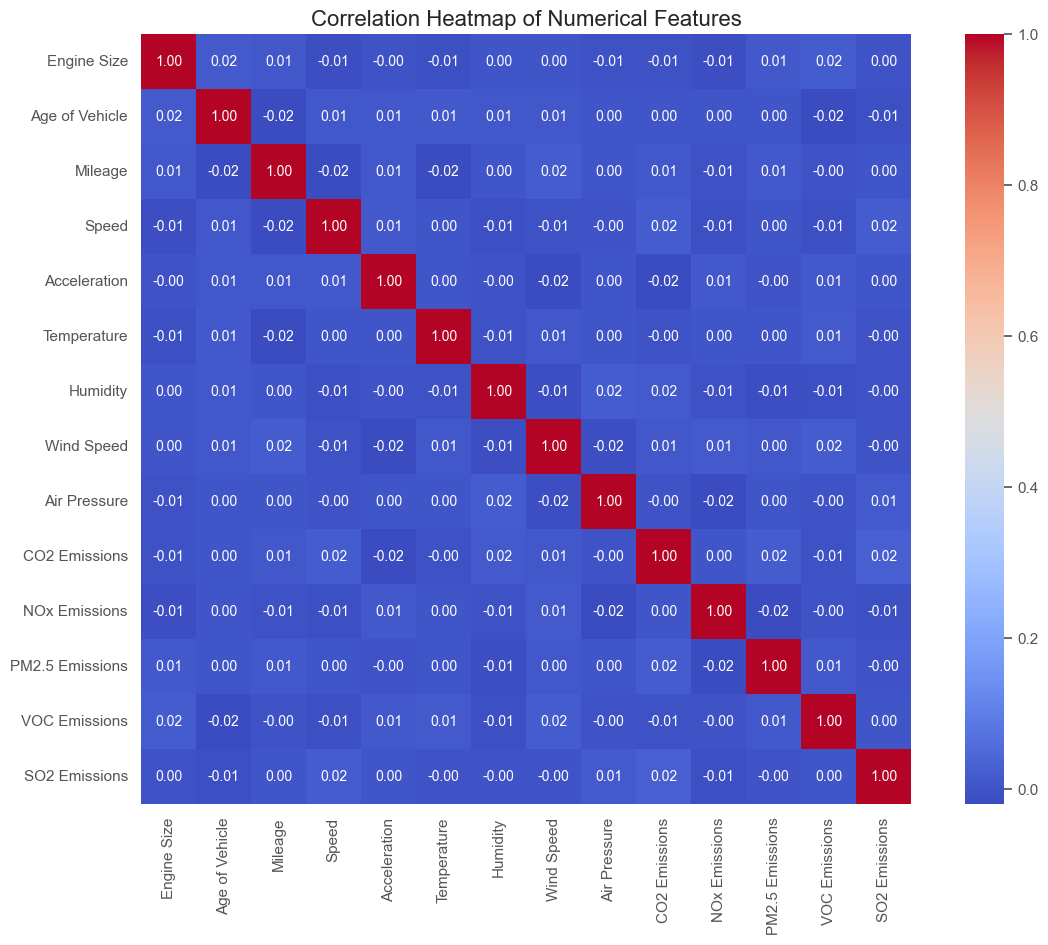

In [22]:
# 🔥 Compute Correlation Matrix for Numerical Features
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# 📈 Plot the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()


# Step 2: Data Preprocessing

We’ll now prep the data for training. This includes:

✅ Encoding categorical variables

📏 Scaling numerical features

🧪 Splitting into train/test sets

#  Step 2.1: Encode Categorical Features

In [23]:
# 🔄 Encode Categorical Features using One-Hot Encoding
categorical_cols = ['Vehicle Type', 'Fuel Type', 'Road Type', 'Traffic Conditions']

# Use get_dummies for One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Show the shape after encoding
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()


Shape after encoding: (10000, 25)


,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,...,Vehicle Type_Car,Vehicle Type_Motorcycle,Vehicle Type_Truck,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Road Type_Highway,Road Type_Rural,Traffic Conditions_Heavy,Traffic Conditions_Moderate
0,2.747609,22,291288,49.083255,1.887738,13.880458,52.883905,18.938861,955.411642,179.930088,...,False,True,False,True,False,False,True,False,False,True
1,5.743714,3,188398,23.460311,3.544147,19.136947,5.697343,14.716526,1035.763062,250.505219,...,False,False,False,True,False,False,False,False,True,False
2,4.606368,17,281451,115.508350,4.646886,8.123428,3.953116,18.644522,976.207064,404.979103,...,False,False,False,False,True,False,True,False,False,False
3,3.913024,4,151321,18.540217,3.581004,35.994893,0.509678,11.951859,966.919462,463.568608,...,False,False,True,True,False,False,False,True,True,False
4,1.611297,15,91810,109.596566,3.879303,14.793481,52.450884,2.761138,953.229351,79.514604,...,False,False,True,False,True,False,True,False,False,True


# Step 2.2: Scale the Numerical Features

We’ll use StandardScaler to normalize the numerical data so all features have a mean of 0 and std dev of 1.

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 📥 Step 1: Load your dataset
df = pd.read_csv("C:/Users/Priyanshu/Desktop/ghg ml model/Dataset/GHG_emission_dataset.csv")  # Update if needed

# 🔄 Step 2: One-hot encode categorical columns
categorical_cols = ['Vehicle Type', 'Fuel Type', 'Road Type', 'Traffic Conditions']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# ✅ Optional: check the shape
print("Shape after encoding:", df_encoded.shape)

# 🎯 Step 3: Define target and features
target_col = 'Emission Level'  # Ensure this column exists in your dataset
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 📏 Step 4: Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)


Shape after encoding: (10000, 29)
Scaled Feature Shape: (10000, 28)


 # Step 2.3: Train-Test Split
 We'll use train_test_split from sklearn to divide the data.

In [25]:
from sklearn.model_selection import train_test_split

# ✂️ Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y  # stratify helps balance Emission Levels
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (8000, 28)
Test set shape: (2000, 28)


# Step 3: Model Training & Evaluation
-3.1 Train Random Forest Classifier

-3.2 Evaluate Accuracy with Classification Report

-3.3 Confusion Matrix

-3.4 Visualize Feature Importances ✅ ← you just completed this



# Step 3.1:Train a Classification Model
We’ll predict the Emission Level (Low, Medium, High), so this is a multiclass classification problem.

We'll start with a simple yet powerful model: RandomForestClassifier.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 🏋️‍♂️ Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔮 Predict on test data
y_pred = model.predict(X_test)

# 📊 Evaluate the model
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       884
         Low       1.00      1.00      1.00       461
      Medium       1.00      1.00      1.00       655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:

[[884   0   0]
 [  0 461   0]
 [  0   0 655]]


### Step 3.2: Visualize Feature Importances  
We now plot which features contributed most to the prediction of the emission level.
This gives insights into which variables have the greatest influence on model decisions.


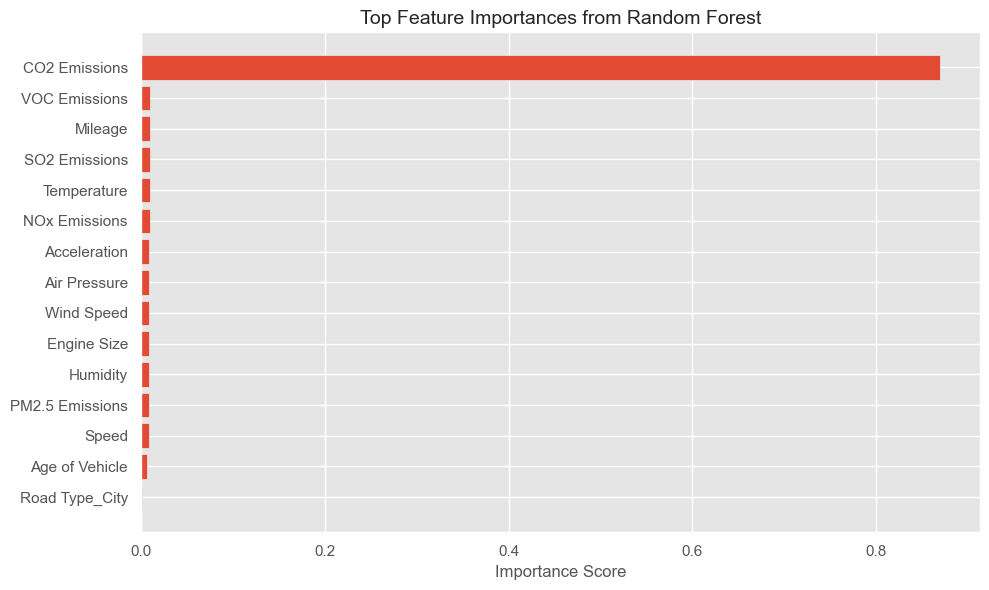

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 🧠 Get feature importances from the trained model
importances = model.feature_importances_
feature_names = X.columns

# 🎯 Sort features by importance (descending)
indices = np.argsort(importances)[::-1]
top_n = 15  # Show top 15 features

# 📊 Plot top features
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances from Random Forest", fontsize=14)
plt.barh(range(top_n), importances[indices][:top_n][::-1], align="center")
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### Step 4.1: Save the Trained Model & Scaler  
We’ll use joblib to save both the model and the scaler, so they can be reused during deployment.


In [28]:
import joblib

# 💾 Save trained model and scaler to .pkl files
joblib.dump(model, "emission_level_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

print("✅ Model and Scaler saved successfully.")


✅ Model and Scaler saved successfully.


# Step 4.2: Create a Streamlit App for Emission Prediction
This app will:

Let the user enter vehicle specs

Scale those inputs using your saved scaler

Use your trained Random Forest model to predict the Emission Level (Low / Medium / High)

In [29]:
# After training X is ready
import joblib
joblib.dump(X.columns.tolist(), "feature_names.pkl")


['feature_names.pkl']